## 🔧 Configuración inicial

Estas celdas cargan las librerías, montan Google Drive y cargan los datos generados por el Cuaderno 1.

In [1]:
# ─── Librerías ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

# Análisis espacial
from libpysal.weights import KNN
from esda import Moran, Moran_Local

# Machine learning
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
!pip install -q optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Explicabilidad
import shap

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


Ahora montamos Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ MODIFICA AQUÍ — Ruta al archivo guardado por el Cuaderno 1 en tu Drive
RUTA_DATOS = "/content/drive/MyDrive/srgvua/datos_para_cuaderno2.gpkg"

# ─── Cargar datos ─────────────────────────────────────────────────────────────
print("⏳ Cargando datos...")
gdf = gpd.read_file(RUTA_DATOS)
print(f"✅ Datos cargados: {gdf.shape[0]:,} filas × {gdf.shape[1]} columnas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Cargando datos...
✅ Datos cargados: 9,168 filas × 53 columnas


In [3]:
# ✏️ MODIFICA AQUÍ — Copia aquí exactamente las mismas variables que usaste
# en el Paso 3 del Cuaderno 1 (celda VARS_MODELO_DEFINITIVO)
VARS_MODELO = [
    'superficie',
    'superficie_2',
    'calidad_construccion',
    'interac_planta_ascensor',
    'distancia_plaza_cat',
    'distancia_fr_macia',
    'num_tp',
]

# Nombre de la columna de variable dependiente y de residuos OLS
# (no cambies esto salvo que hayas modificado los nombres en el Cuaderno 1)
COL_Y       = 'log_precio_euros'
COL_RES_OLS = 'residuos_ols_C'

print(f"   Variable dependiente : {COL_Y}")
print(f"   Variables explicativas: {VARS_MODELO}")
print(f"   Columna residuos OLS : {COL_RES_OLS}")

   Variable dependiente : log_precio_euros
   Variables explicativas: ['superficie', 'superficie_2', 'calidad_construccion', 'interac_planta_ascensor', 'distancia_plaza_cat', 'distancia_fr_macia', 'num_tp']
   Columna residuos OLS : residuos_ols_C


---
## Paso 4 — I de Moran global y local (LISA)

El **índice I de Moran** mide si los valores similares tienden a agruparse espacialmente (*autocorrelación positiva*) o si se dispersan (*autocorrelación negativa*).

- **I global**: un único número que resume la autocorrelación de todo el espacio.
- **I local (LISA)**: clasifica cada punto en cuadrantes según cómo se relaciona con sus vecinos:
  - 🔴 **HH** (*High-High*): valores altos rodeados de valores altos → clúster de valores altos
  - 🔵 **LL** (*Low-Low*): valores bajos rodeados de bajos → clúster de valores bajos
  - 🟠 **HL** (*High-Low*): valor alto rodeado de valores bajos → *outlier* espacial
  - 🩵 **LH** (*Low-High*): valor bajo rodeado de valores altos → *outlier* espacial
  - ⬜ **No significativo**: sin patrón espacial claro

La matriz de vecindad será **k-NN con k=15**: cada punto toma como vecinos sus 15 propiedades más cercanas.

In [4]:
# ✏️ Modifica según tu interés — Variables para el análisis de Moran
VARIABLES_MORAN = ['precio_euros', 'precio_unitario', 'superficie']

# ✏️ Esto lo puedes modificar e ir probando — Número de vecinos (k) para la matriz espacial
K_VECINOS = 15

In [5]:
# Se trabaja sólo con observaciones que tienen geometría válida
#Esto es sólo por si acaso
gdf_valido = gdf[gdf.geometry.notna()].copy().reset_index(drop=True) 

# Y ahora sí construimos la matriz
w = KNN.from_dataframe(gdf_valido, k=K_VECINOS)
w.transform = 'r'   # Estandarización por filas (cada fila de la matriz suma 1)

print("✅ Matriz de pesos espaciales creada:")

✅ Matriz de pesos espaciales creada:


Dado que no hay una librería que de manera automática nos calcule la I de Moran, vamos a definir unas funciones para ello.

In [6]:
# ─── Funciones auxiliares — Moran, LISA y mapas ───────────────────────────────
# Estas funciones se usan a lo largo del cuaderno. No es necesario modificarlas.

def moran_global_tabla(variables, gdf_local, w_local):
    """
    Calcula la I de Moran global para una lista de variables.
    Devuelve un DataFrame con los resultados.
    """
    resultados = []
    for var in variables:
        valores = gdf_local[var].fillna(gdf_local[var].median()).values
        m = Moran(valores, w_local)
        resultados.append({
            'Variable': var,
            'I de Moran': round(m.I, 4),
            'z-score': round(m.z_sim, 4),
            'p-valor': round(m.p_sim, 4),
            'Significativo (p<0.05)': '✅ Sí' if m.p_sim < 0.05 else '❌ No'
        })
    return pd.DataFrame(resultados)


def clasificar_lisa(lisa, p_threshold=0.05):
    """
    Clasifica observaciones en cuadrantes LISA.
    Cuadrantes: HH, LL, LH, HL, No significativo.
    """
    clasificacion = np.full(len(lisa.p_sim), 'No significativo', dtype=object)
    sig = lisa.p_sim <= p_threshold
    clasificacion[sig & (lisa.q == 1)] = 'HH'
    clasificacion[sig & (lisa.q == 2)] = 'LH'
    clasificacion[sig & (lisa.q == 3)] = 'LL'
    clasificacion[sig & (lisa.q == 4)] = 'HL'
    return clasificacion


COLORES_LISA = {
    'HH': '#d7191c',
    'LL': '#2c7bb6',
    'LH': '#abd9e9',
    'HL': '#fdae61',
    'No significativo': '#cccccc'
}


def mapa_lisa(gdf_local, col_clasificacion, titulo='LISA', ax=None):
    """
    Dibuja un mapa coroplético con los cuadrantes LISA.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
    for cat, color in COLORES_LISA.items():
        datos = gdf_local[gdf_local[col_clasificacion] == cat]
        if len(datos) > 0:
            datos.plot(ax=ax, color=color, markersize=5, alpha=0.5, linewidth=0)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.axis('off')
    patches = [
        mpatches.Patch(color=c, label=f"{cat} (n={len(gdf_local[gdf_local[col_clasificacion]==cat]):,})")
        for cat, c in COLORES_LISA.items()
        if len(gdf_local[gdf_local[col_clasificacion] == cat]) > 0
    ]
    ax.legend(handles=patches, loc='upper left', fontsize=8, framealpha=0.9)


def mapa_residuos(gdf, col, titulo='Residuos', ax=None,
                  q_min=0.10, q_max=0.90, cmap='RdBu',
                  markersize=4.5, label_leyenda='Residuos'):
    """
    Mapa de puntos coloreado por valor de residuos.
    La escala de color se centra en el rango percentílico [q_min, q_max].
    Si ax=None, crea su propia figura y la muestra directamente.
    """
    crear_fig = (ax is None)
    if crear_fig:
        fig_local, ax_plot = plt.subplots(figsize=(10, 8))
    else:
        ax_plot = ax

    datos = gdf[gdf[col].notna()].copy()
    vmin  = datos[col].quantile(q_min)
    vmax  = datos[col].quantile(q_max)

    datos.plot(
        column=col, cmap=cmap, ax=ax_plot,
        alpha=0.5, markersize=markersize, linewidth=0,
        legend=True, vmin=vmin, vmax=vmax,
        legend_kwds={'label': label_leyenda, 'shrink': 0.7}
    )
    ax_plot.set_title(titulo, fontsize=12, fontweight='bold')
    ax_plot.axis('off')

    if crear_fig:
        plt.tight_layout()
        plt.show()


print("✅ Funciones auxiliares definidas: moran_global_tabla | clasificar_lisa | mapa_lisa | mapa_residuos")


✅ Funciones auxiliares definidas: moran_global_tabla | clasificar_lisa | mapa_lisa | mapa_residuos


In [7]:
# ─── I de Moran global ────────────────────────────────────────────────────────

tabla_moran = moran_global_tabla(VARIABLES_MORAN, gdf_valido, w)

print("="*65)
print("I DE MORAN GLOBAL")
print("="*65)
print(tabla_moran.to_string(index=False))
print("="*65)

I DE MORAN GLOBAL
       Variable  I de Moran  z-score  p-valor Significativo (p<0.05)
   precio_euros      0.5905 157.8201    0.001                   ✅ Sí
precio_unitario      0.5469 146.1611    0.001                   ✅ Sí
     superficie      0.4188 119.2102    0.001                   ✅ Sí


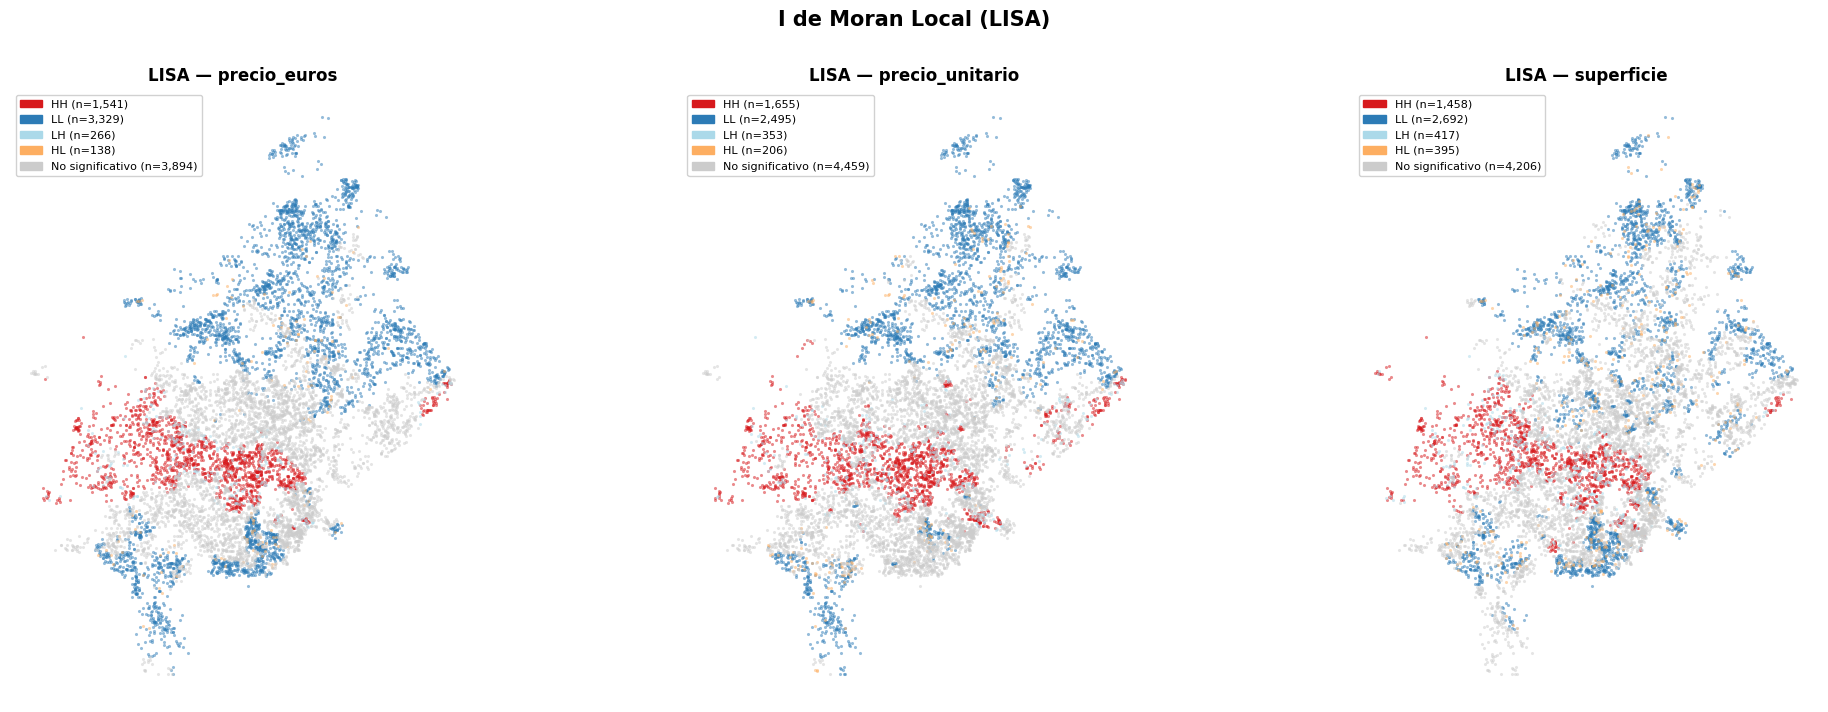

In [8]:
# ─── I de Moran local (LISA) y mapas ─────────────────────────────────────────

n_vars = len(VARIABLES_MORAN)
fig, axes = plt.subplots(1, n_vars, figsize=(7 * n_vars, 7))
if n_vars == 1:
    axes = [axes]

for i, var in enumerate(VARIABLES_MORAN): # Noten que VARIABLES_MORAN se definió al inicio del cuaderno
    valores = gdf_valido[var].fillna(gdf_valido[var].median()).values
    lisa = Moran_Local(valores, w)
    col_lisa = f'lisa_{var}'
    gdf_valido[col_lisa] = clasificar_lisa(lisa)
    mapa_lisa(gdf_valido, col_lisa, titulo=f'LISA — {var}', ax=axes[i])

plt.suptitle('I de Moran Local (LISA)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Paso 5 — I de Moran de los residuos del OLS definitivo

Si los residuos de un modelo OLS muestran autocorrelación espacial, significa que el modelo no ha capturado toda la estructura espacial de los datos. Esto sugiere que podría ser mejor usar un modelo espacial explícito, o bien un modelo más flexible como XGBoost.

> **Interpretación clave:** Si I de Moran de los residuos es significativo, el modelo OLS viola el supuesto de independencia de los errores.

In [9]:
# ─── Moran global de los residuos OLS ────────────────────────────────────────

# Usar solo las filas donde el residuo no es nulo
mask_res = gdf_valido[COL_RES_OLS].notna() # Noten que COL_RES_OLS se definió al inicio del cuaderno

# Alerta si el número de filas con residuos difiere del tamaño de la matriz
n_res = mask_res.sum()
if n_res != w.n:
    print(f"⚠️  Hay {w.n - n_res} filas sin residuos OLS. Se imputará la mediana.")

residuos_ols = gdf_valido[COL_RES_OLS].fillna(gdf_valido[COL_RES_OLS].median()).values # Noten que COL_RES_OLS se definió al inicio del cuaderno

moran_res = Moran(residuos_ols, w)

print("="*60)
print("I DE MORAN GLOBAL — Residuos OLS definitivo")
print("="*60)
print(f"  I de Moran : {moran_res.I:.4f}")
print(f"  z-score    : {moran_res.z_sim:.4f}")
print(f"  p-valor    : {moran_res.p_sim:.4f}")
print("─"*60)
if moran_res.p_sim < 0.05:
    print("  → Existe autocorrelación espacial significativa en los residuos.")
    print("    El OLS no captura toda la estructura espacial.")
else:
    print("  → No se detecta autocorrelación espacial significativa.")
print("="*60)

I DE MORAN GLOBAL — Residuos OLS definitivo
  I de Moran : 0.2655
  z-score    : 72.2625
  p-valor    : 0.0010
────────────────────────────────────────────────────────────
  → Existe autocorrelación espacial significativa en los residuos.
    El OLS no captura toda la estructura espacial.


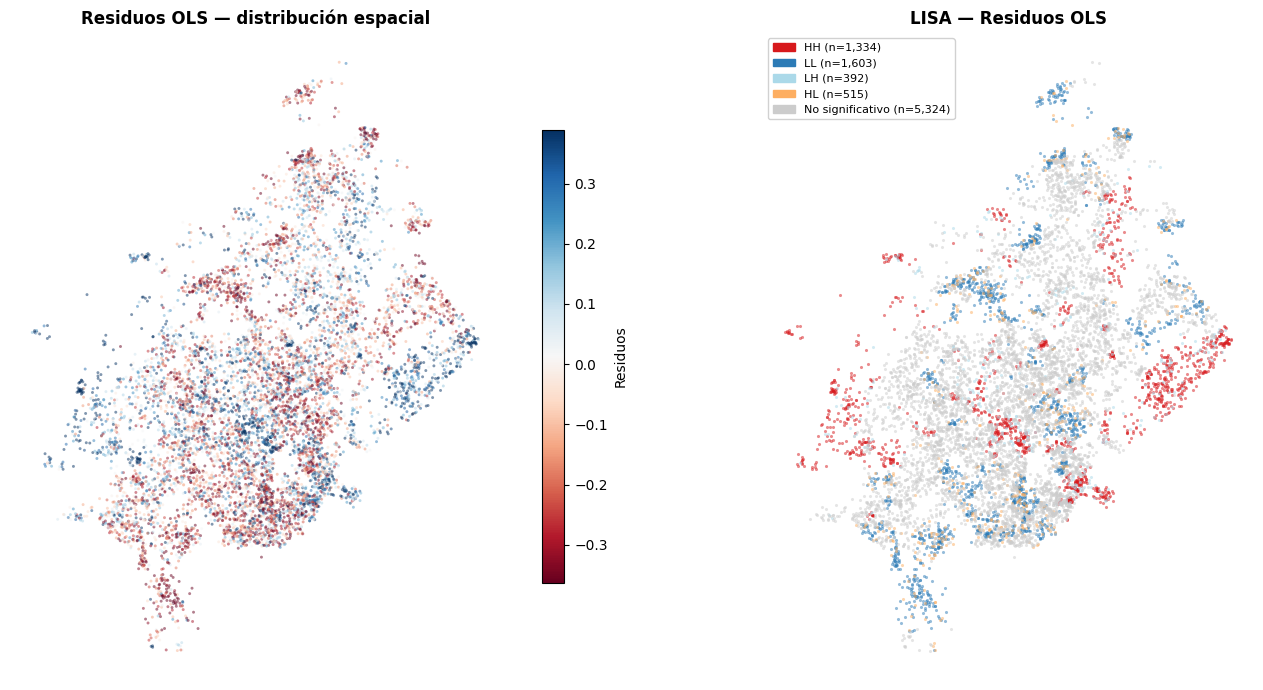

In [10]:
# ─── LISA de los residuos OLS ────────────────────────────────────────────────

lisa_res_ols = Moran_Local(residuos_ols, w)
gdf_valido['lisa_residuos_ols'] = clasificar_lisa(lisa_res_ols)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mapa_residuos(gdf_valido, COL_RES_OLS,               # COL_RES_OLS definido al inicio del cuaderno
              titulo='Residuos OLS — distribución espacial',
              ax=axes[0], q_min=0.10, q_max=0.90)

mapa_lisa(gdf_valido, 'lisa_residuos_ols',
          titulo='LISA — Residuos OLS', ax=axes[1])

plt.tight_layout()
plt.show()


---
## Paso 6 — Modelo XGBoost con optimización *Optuna*

**XGBoost** (*Extreme Gradient Boosting*) es un algoritmo de *machine learning* basado en árboles de decisión. A diferencia del OLS, no asume ninguna relación lineal entre las variables y puede capturar patrones complejos.

Para encontrar la mejor combinación de parámetros, usamos **Optuna**, una librería de optimización automática. Probará varias combinaciones y quedará con la que minimiza el error.

### Parámetros del XGBoost

| Parámetro | ¿Qué controla? |
|---|---|
| `n_estimators` | Número de árboles que se construyen en secuencia |
| `max_depth` | Profundidad máxima de cada árbol (más profundo = más complejo) |
| `learning_rate` | Cuánto aprende el modelo en cada paso (más pequeño = más gradual) |
| `subsample` | Fracción aleatoria de observaciones usadas en cada árbol |
| `colsample_bytree` | Fracción aleatoria de variables usadas en cada árbol |
| `random_state` | Semilla para reproducibilidad (mismos resultados cada vez) |

In [11]:
# ✏️ MODIFICA AQUÍ — Configuración del XGBoost

# Fracción de datos para entrenamiento (el resto se usa para evaluación)
PROPORCION_TRAIN = 0.70    # 70% entrenamiento, 30% test

# Número de combinaciones que Optuna probará (más = mejor resultado, pero más tiempo)
N_TRIALS_OPTUNA = 50

# Semilla para reproducibilidad
SEMILLA = 16

In [12]:
# ─── Preparar datos para XGBoost ──────────────────────────────────────────────

datos_xgb = gdf_valido[VARS_MODELO + [COL_Y]].dropna()

X_xgb = datos_xgb[VARS_MODELO].values
y_xgb = datos_xgb[COL_Y].values

# División 70% train / 30% test
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_xgb, y_xgb, datos_xgb.index,
    test_size=1 - PROPORCION_TRAIN,
    random_state=SEMILLA
)

print(f"✅ Datos preparados:")
print(f"   Total: {len(datos_xgb):,} observaciones")
print(f"   Train: {len(X_train):,} ({PROPORCION_TRAIN*100:.0f}%)")
print(f"   Test:  {len(X_test):,} ({(1-PROPORCION_TRAIN)*100:.0f}%)")

✅ Datos preparados:
   Total: 9,168 observaciones
   Train: 6,417 (70%)
   Test:  2,751 (30%)


In [13]:
# ─── Optimización de hiperparámetros con Optuna ───────────────────────────────

def objetivo(trial):
    """Función que Optuna minimizará (RMSE en el conjunto de test)."""
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state':      SEMILLA,
        'n_jobs':            -1,
        'verbosity':         0,
    }
    modelo = XGBRegressor(**params)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

print(f"⏳ Ejecutando {N_TRIALS_OPTUNA} pruebas de Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objetivo, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

mejores_params = study.best_params
mejores_params['random_state'] = SEMILLA
mejores_params['n_jobs'] = -1
mejores_params['verbosity'] = 0

print(f"\n✅ Optimización completada")
print(f"   RMSE óptimo (test): {study.best_value:.6f}")
print(f"   Mejores parámetros:")
for k, v in mejores_params.items():
    if k not in ('n_jobs', 'verbosity', 'random_state'):
        print(f"      {k}: {v}")

⏳ Ejecutando 50 pruebas de Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optimización completada
   RMSE óptimo (test): 0.255424
   Mejores parámetros:
      n_estimators: 623
      max_depth: 6
      learning_rate: 0.030749359323194538
      subsample: 0.9420087422308201
      colsample_bytree: 0.8373681679541797


In [14]:
# ─── Entrenar modelo XGBoost final con los mejores parámetros ─────────────────

xgb_final = XGBRegressor(**mejores_params)
xgb_final.fit(X_train, y_train)

# Métricas en train y test
pred_train = xgb_final.predict(X_train)
pred_test  = xgb_final.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  pred_test))
r2_train   = r2_score(y_train, pred_train)
r2_test    = r2_score(y_test,  pred_test)

print("="*50)
print("MÉTRICAS — XGBoost")
print("="*50)
print(f"  {'':15} {'Train':>10} {'Test':>10}")
print(f"  {'RMSE':15} {rmse_train:>10.4f} {rmse_test:>10.4f}")
print(f"  {'R²':15} {r2_train:>10.4f} {r2_test:>10.4f}")
print("="*50)

MÉTRICAS — XGBoost
                       Train       Test
  RMSE                0.1866     0.2554
  R²                  0.9179     0.8383


---
## Paso 7 — Valores SHAP

Los **valores SHAP** (*SHapley Additive exPlanations*) miden la contribución de cada variable a la predicción del modelo para cada observación.

El **beeswarm plot** muestra, para cada variable:
- Cuánto contribuye a aumentar o reducir la predicción (eje horizontal)
- La distribución de esas contribuciones en todo el dataset
- El valor de la variable codificado en color (azul = bajo, rojo = alto)

⏳ Calculando SHAP values...


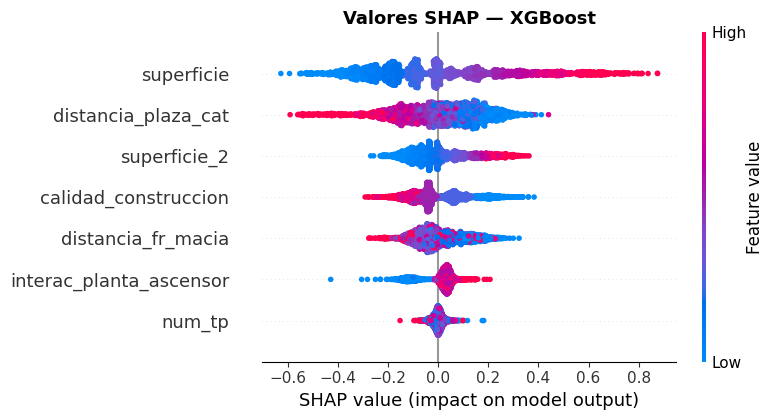


IMPORTANCIA DE VARIABLES (|SHAP| promedio)
               Variable  Importancia media |SHAP|
             superficie                    0.2325
    distancia_plaza_cat                    0.1333
           superficie_2                    0.0947
   calidad_construccion                    0.0918
     distancia_fr_macia                    0.0748
interac_planta_ascensor                    0.0528
                 num_tp                    0.0160


In [15]:
# ─── Calcular y visualizar SHAP values ───────────────────────────────────────

print("⏳ Calculando SHAP values...")
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=VARS_MODELO,
    show=False,
    plot_type='dot'
)
plt.title('Valores SHAP — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de importancia media (|SHAP|)
importancia_shap = pd.DataFrame({
    'Variable': VARS_MODELO,
    'Importancia media |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Importancia media |SHAP|', ascending=False).reset_index(drop=True)
importancia_shap['Importancia media |SHAP|'] = importancia_shap['Importancia media |SHAP|'].round(4)

print("\n" + "="*50)
print("IMPORTANCIA DE VARIABLES (|SHAP| promedio)")
print("="*50)
print(importancia_shap.to_string(index=False))
print("="*50)

---
## Paso 8 — Residuos del XGBoost en el 100 % de los datos

Aunque el modelo se entrenó con el 70 % de los datos, ahora predecimos para **todas** las observaciones disponibles y guardamos los residuos.

In [16]:
# ─── Predicción en el 100% de los datos ──────────────────────────────────────

pred_total = xgb_final.predict(X_xgb)
residuos_xgb = y_xgb - pred_total

# Guardar en gdf_valido
gdf_valido['pred_xgb']      = np.nan
gdf_valido['residuos_xgb']  = np.nan

gdf_valido.loc[datos_xgb.index, 'pred_xgb']     = pred_total
gdf_valido.loc[datos_xgb.index, 'residuos_xgb'] = residuos_xgb

print(f"✅ Residuos XGBoost guardados en columna 'residuos_xgb'")
print(f"   Observaciones con residuos: {gdf_valido['residuos_xgb'].notna().sum():,}")

✅ Residuos XGBoost guardados en columna 'residuos_xgb'
   Observaciones con residuos: 9,168


---
## Paso 9 — Histograma y mapa de residuos del XGBoost

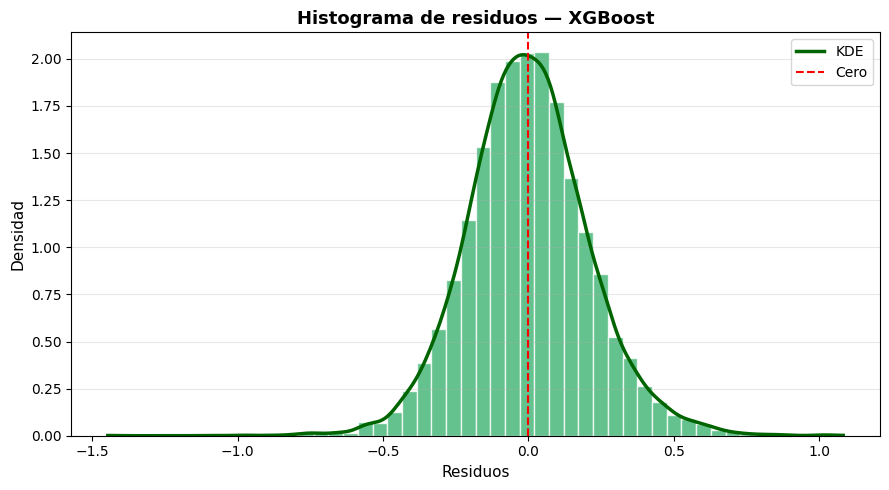

In [17]:
# ─── Histograma de residuos XGBoost ──────────────────────────────────────────

res_xgb_validos = gdf_valido['residuos_xgb'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(res_xgb_validos, bins=50, density=True, color='mediumseagreen', edgecolor='white', alpha=0.8)

# Curva KDE
kde = gaussian_kde(res_xgb_validos)
x_range = np.linspace(res_xgb_validos.min(), res_xgb_validos.max(), 300)
ax.plot(x_range, kde(x_range), color='darkgreen', linewidth=2.5, label='KDE')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Cero')

ax.set_xlabel('Residuos', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Histograma de residuos — XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

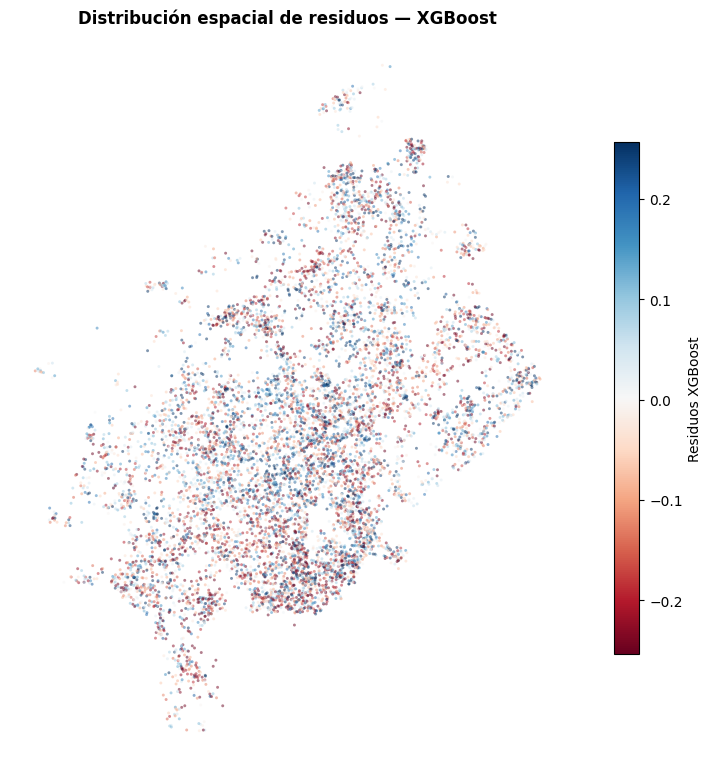

In [18]:
# ─── Mapa de residuos XGBoost ─────────────────────────────────────────────────

mapa_residuos(
    gdf_valido, 'residuos_xgb',
    titulo='Distribución espacial de residuos — XGBoost',
    q_min=0.10, q_max=0.90,
    label_leyenda='Residuos XGBoost',
    markersize=4.5
)


---
## Paso 10 — Comparación OLS vs XGBoost

Comparamos visualmente los residuos de ambos modelos mediante:
1. **Histogramas superpuestos**: distribución de errores de cada modelo.
2. **Mapas comparativos**: dónde se concentran los errores de cada modelo.

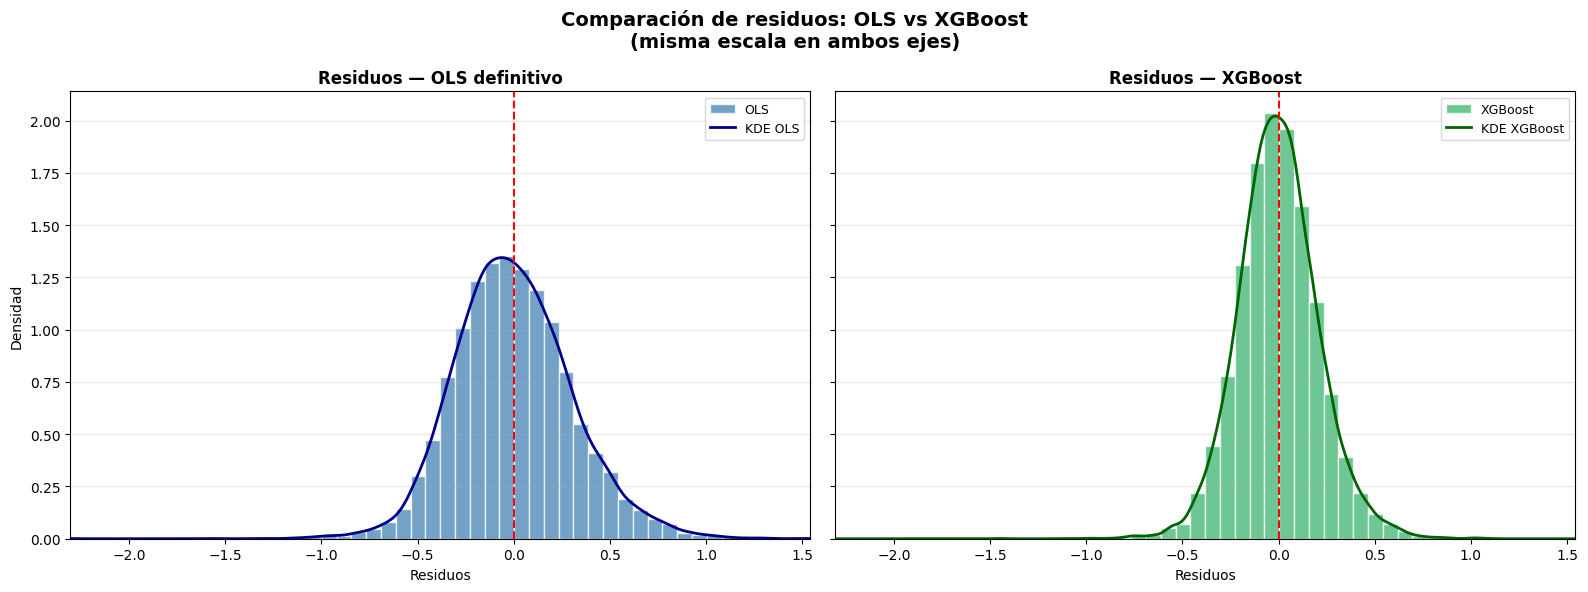

COMPARACIÓN NUMÉRICA DE RESIDUOS
  Métrica                            OLS      XGBoost
  ─────────────────────────────────────────────────
  Media                          -0.0000      -0.0016
  Desv. típica                    0.3058       0.2097
  Mínimo                         -2.3076      -1.4458
  Máximo                          1.5433       1.0820
  RMSE                            0.3058       0.2097


In [19]:
# ─── Comparación de histogramas de residuos ───────────────────────────────────

res_ols = gdf_valido[COL_RES_OLS].dropna()
res_xgb = gdf_valido['residuos_xgb'].dropna()

# Rango y bins comunes para que ambos histogramas sean directamente comparables
x_min = min(res_ols.min(), res_xgb.min())
x_max = max(res_ols.max(), res_xgb.max())
bins_comunes = np.linspace(x_min, x_max, 51)  # 50 intervalos idénticos en ambos paneles

# sharey=True comparte el eje Y automáticamente
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ── Panel izquierdo: OLS ──
axes[0].hist(res_ols, bins=bins_comunes, density=True, color='steelblue', edgecolor='white', alpha=0.75, label='OLS')
kde_ols = gaussian_kde(res_ols)
x_ols = np.linspace(x_min, x_max, 300)
axes[0].plot(x_ols, kde_ols(x_ols), color='darkblue', linewidth=2, label='KDE OLS')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlim(x_min, x_max)
axes[0].set_title('Residuos — OLS definitivo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Panel derecho: XGBoost ──
axes[1].hist(res_xgb, bins=bins_comunes, density=True, color='mediumseagreen', edgecolor='white', alpha=0.75, label='XGBoost')
kde_xgb = gaussian_kde(res_xgb)
x_xgb = np.linspace(x_min, x_max, 300)
axes[1].plot(x_xgb, kde_xgb(x_xgb), color='darkgreen', linewidth=2, label='KDE XGBoost')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlim(x_min, x_max)
axes[1].set_title('Residuos — XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuos')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación de residuos: OLS vs XGBoost\n(misma escala en ambos ejes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Tabla resumen de errores ──
print("="*55)
print("COMPARACIÓN NUMÉRICA DE RESIDUOS")
print("="*55)
print(f"  {'Métrica':25} {'OLS':>12} {'XGBoost':>12}")
print(f"  {'─'*49}")
print(f"  {'Media':25} {res_ols.mean():>12.4f} {res_xgb.mean():>12.4f}")
print(f"  {'Desv. típica':25} {res_ols.std():>12.4f} {res_xgb.std():>12.4f}")
print(f"  {'Mínimo':25} {res_ols.min():>12.4f} {res_xgb.min():>12.4f}")
print(f"  {'Máximo':25} {res_ols.max():>12.4f} {res_xgb.max():>12.4f}")
print(f"  {'RMSE':25} {np.sqrt((res_ols**2).mean()):>12.4f} {np.sqrt((res_xgb**2).mean()):>12.4f}")
print("="*55)

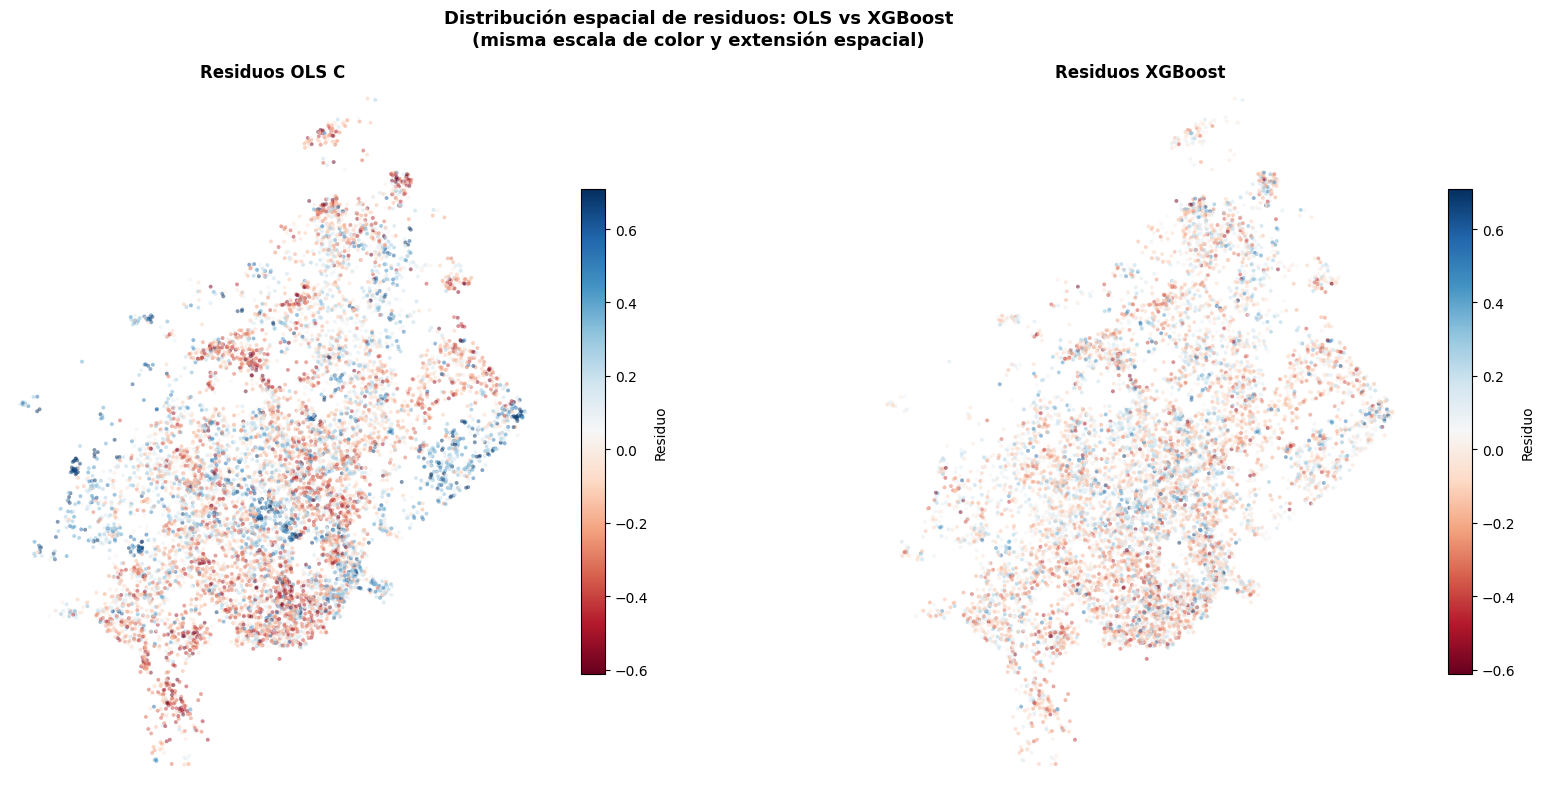

In [20]:
# ─── Comparación de mapas de residuos ─────────────────────────────────────────
# Para que los mapas sean comparables, usamos la misma escala de color
# Y los mismos límites espaciales en ambos paneles

gdf_ols_plot = gdf_valido[gdf_valido[COL_RES_OLS].notna()].copy()
gdf_xgb_plot = gdf_valido[gdf_valido['residuos_xgb'].notna()].copy()

# Escala de color común: percentil 1 y 99 de ambos conjuntos de residuos
todos_residuos = pd.concat([res_ols, res_xgb])
vmin = todos_residuos.quantile(0.01)
vmax = todos_residuos.quantile(0.99)

# Límites espaciales comunes: unión de ambas capas
bounds = gdf_valido.total_bounds  # [xmin, ymin, xmax, ymax]
xmin, ymin, xmax, ymax = bounds
margen_x = (xmax - xmin) * 0.02
margen_y = (ymax - ymin) * 0.02

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Panel izquierdo: OLS ──
gdf_ols_plot.plot(
    column=COL_RES_OLS, # Noten que COL_RES_OLS se definió al inicio del cuaderno
    cmap='RdBu',
    ax=axes[0],
    vmin=vmin, vmax=vmax,
    alpha=0.5, markersize=8, linewidth=0,
    legend=True,
    legend_kwds={'label': 'Residuo', 'shrink': 0.7}
)
axes[0].set_title('Residuos OLS C', fontsize=12, fontweight='bold')
axes[0].set_xlim(xmin - margen_x, xmax + margen_x)
axes[0].set_ylim(ymin - margen_y, ymax + margen_y)
axes[0].axis('off')

# ── Panel derecho: XGBoost ──
gdf_xgb_plot.plot(
    column='residuos_xgb',
    cmap='RdBu',
    ax=axes[1],
    vmin=vmin, vmax=vmax,
    alpha=0.5, markersize=8, linewidth=0,
    legend=True,
    legend_kwds={'label': 'Residuo', 'shrink': 0.7}
)
axes[1].set_title('Residuos XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlim(xmin - margen_x, xmax + margen_x)
axes[1].set_ylim(ymin - margen_y, ymax + margen_y)
axes[1].axis('off')

plt.suptitle('Distribución espacial de residuos: OLS vs XGBoost\n(misma escala de color y extensión espacial)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Paso 11 — Exportar resultados a Google Drive

Guardamos dos archivos en tu Drive:

| Archivo | Contenido |
|---|---|
| `datos_con_residuos.gpkg` | GeoPackage con todas las observaciones y las columnas de residuos OLS y XGBoost |
| `modelo_xgboost.json` | Modelo XGBoost entrenado (se puede cargar en cualquier sesión futura) |


In [21]:
# ✏️ MODIFICA AQUÍ — Rutas de salida en tu Google Drive
RUTA_DATOS_SALIDA  = "/content/drive/MyDrive/srgvua/datos_con_residuos.gpkg"
RUTA_MODELO_SALIDA = "/content/drive/MyDrive/srgvua/modelo_xgboost.json"

# ─── Crear carpeta si no existe ───────────────────────────────────────────────
carpeta = os.path.dirname(RUTA_DATOS_SALIDA)
os.makedirs(carpeta, exist_ok=True)

# ─── Guardar GeoPackage con residuos ─────────────────────────────────────────
# Columnas a conservar: geometría + variables del modelo + residuos de ambos modelos
cols_exportar = ['geometry', COL_Y] + VARS_MODELO + [COL_RES_OLS, 'residuos_xgb', 'pred_xgb']
cols_exportar = [c for c in cols_exportar if c in gdf_valido.columns]

gdf_export = gdf_valido[cols_exportar].copy()
gdf_export.to_file(RUTA_DATOS_SALIDA, driver='GPKG')
print(f"✅ GeoPackage guardado ({len(gdf_export):,} filas, {len(cols_exportar)} columnas)")
print(f"   → {RUTA_DATOS_SALIDA}")

# ─── Guardar modelo XGBoost ───────────────────────────────────────────────────
xgb_final.save_model(RUTA_MODELO_SALIDA)
print(f"\n✅ Modelo XGBoost guardado")
print(f"   → {RUTA_MODELO_SALIDA}")

# ─── Cómo cargarlo en el futuro ───────────────────────────────────────────────
print("\n💡 Para cargar el modelo en otra sesión:")
print("   from xgboost import XGBRegressor")
print(f"   modelo = XGBRegressor()")
print(f"   modelo.load_model('{RUTA_MODELO_SALIDA}')")


✅ GeoPackage guardado (9,168 filas, 12 columnas)
   → /content/drive/MyDrive/srgvua/datos_con_residuos.gpkg

✅ Modelo XGBoost guardado
   → /content/drive/MyDrive/srgvua/modelo_xgboost.json

💡 Para cargar el modelo en otra sesión:
   from xgboost import XGBRegressor
   modelo = XGBRegressor()
   modelo.load_model('/content/drive/MyDrive/srgvua/modelo_xgboost.json')
